In [1]:
#load dependencies
import fastf1
import pandas
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Constants
fuelQuantity = 110           # Total fuel in kg
totalLapNumber = 58          # Total number of laps
timePerKg = 0.03            # Time lost per kg of fuel in seconds

# Fuel consumption per lap
fuelConsumption = fuelQuantity / totalLapNumber  # kg consumed per lap

# List to store fuel correction per lap
fuelLapCorrections = []

# Loop through each lap to calculate fuel correction
for lap in range(1, totalLapNumber + 1):
    fuelCorrectionFactor = fuelConsumption * timePerKg
    fuelCorrectionForLap = fuelCorrectionFactor * (totalLapNumber - lap)
    fuelLapCorrections.append(fuelCorrectionForLap)

# Output: list of fuel corrections per lap
print(fuelLapCorrections)

[3.243103448275862, 3.186206896551724, 3.129310344827586, 3.072413793103448, 3.0155172413793103, 2.9586206896551723, 2.9017241379310343, 2.8448275862068964, 2.7879310344827584, 2.7310344827586204, 2.6741379310344824, 2.617241379310345, 2.560344827586207, 2.503448275862069, 2.446551724137931, 2.389655172413793, 2.332758620689655, 2.275862068965517, 2.2189655172413794, 2.1620689655172414, 2.1051724137931034, 2.0482758620689654, 1.9913793103448274, 1.9344827586206894, 1.8775862068965516, 1.8206896551724137, 1.7637931034482757, 1.706896551724138, 1.65, 1.593103448275862, 1.536206896551724, 1.4793103448275862, 1.4224137931034482, 1.3655172413793102, 1.3086206896551724, 1.2517241379310344, 1.1948275862068964, 1.1379310344827585, 1.0810344827586207, 1.0241379310344827, 0.9672413793103447, 0.9103448275862068, 0.853448275862069, 0.796551724137931, 0.7396551724137931, 0.6827586206896551, 0.6258620689655172, 0.5689655172413792, 0.5120689655172413, 0.4551724137931034, 0.3982758620689655, 0.3413793

In [5]:
# Constants for tyre wear factors
c5Wear = 0.110    # C5 wear in seconds per lap
c4Wear = 0.070    # C4 wear in seconds per lap
c3Wear = 0.050    # C3 wear in seconds per lap

c5InitialLaptime = 88.000
c4InitialLaptime = 88.700
c3InitialLaptime = 89.300


# Assuming total laps in the race
totalLapNumber = 58

# Starting with fresh tires (lap 1)
tyreAge = list(range(1, totalLapNumber + 1))

# Fuel correction per lap (as previously calculated)
fuelQuantity = 110           # Total fuel in kg
timePerKg = 0.03            # Time lost per kg of fuel in seconds
fuelConsumption = fuelQuantity / totalLapNumber

# Lists to store lap times
c5LapTimes = []
c4LapTimes = []
c3LapTimes = []

# Loop through each lap and calculate lap times with tire degradation
for lap in range(1, totalLapNumber + 1):
    # Tire degradation for each compound
    c5TyreDegLaptime = c5InitialLaptime + (c5Wear * np.exp(0.13 * (lap - 1)))
    c4TyreDegLaptime = c4InitialLaptime + (c4Wear * np.exp(0.0975 *(lap - 1)))
    c3TyreDegLaptime = c3InitialLaptime + (c3Wear * np.exp(0.0875 *(lap - 1)))
    
    # Append the lap times to their respective lists
    c5LapTimes.append(c5TyreDegLaptime)
    c4LapTimes.append(c4TyreDegLaptime)
    c3LapTimes.append(c3TyreDegLaptime)

# Output the lap times for the first few laps to check
print("C5 Lap Times:", c5LapTimes[:5])  # Print first 5 laps for C5 compound
print("C4 Lap Times:", c4LapTimes[:5])  # Print first 5 laps for C4 compound
print("C3 Lap Times:", c3LapTimes[:5])  # Print first 5 laps for C3 compound

C5 Lap Times: [88.11, 88.12527112216571, 88.14266230953324, 88.1624678873271, 88.18502304146688]
C4 Lap Times: [88.77, 88.77716880090944, 88.78507176905428, 88.79378409155947, 88.8033886555718]
C3 Lap Times: [89.35, 89.35457211322215, 89.35956231083061, 89.36500882340842, 89.37095337742966]


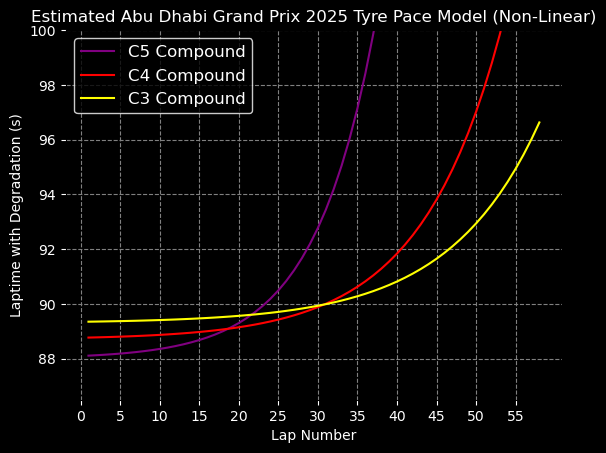

In [7]:
lapNumber = range(1, totalLapNumber + 1)  # List of lap numbers
# Use the previously calculated lap times for C5, C4, and C3 compounds
# (these should be lists of lap times for each lap)


# Create a figure with a black background
fig, ax = plt.subplots()
fig.patch.set_facecolor('black')  # Set the figure background color to black
ax.set_facecolor('black')         # Set the axes background color to black


# Plot the lap times for each compound
plt.plot(lapNumber, c5LapTimes, label="C5 Compound",color="purple")
plt.plot(lapNumber, c4LapTimes, label="C4 Compound",color="red")
plt.plot(lapNumber, c3LapTimes, label="C3 Compound",color="yellow")

# Add title and labels
plt.title("Estimated Abu Dhabi Grand Prix 2025 Tyre Pace Model (Non-Linear)",color="white")
plt.xlabel("Lap Number",color="white")
plt.ylabel("Laptime with Degradation (s)",color="white")
plt.ylim(86.5,100)
plt.xticks(np.arange(0, totalLapNumber + 1, 5))

# Customize tick colors for visibility
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# Set grid color and style (optional)
ax.grid(True, color="gray", linestyle="--")

# Show the legend with a white font color
plt.legend(facecolor="black", edgecolor="white", fontsize='large', labelcolor='white')

# Display the plot
plt.show()